In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Librerie per il Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [10]:
#caricamento del dataset
df = pd.read_csv('cleaned_manga_dataset.csv')
df.head()

,Manga series,Author(s),Publisher,Demographic,No. of collected volumes,Serialized,Approximate sales in million(s),Average sales per volume in million(s),Start_Year
0,One Piece,Eiichiro Oda,Shueisha,Shōnen,104,1997–present,516.6,4.97,1997
1,Golgo 13,"Takao Saito, Saito Production",Shogakukan,Seinen,207,1968–present,300.0,1.45,1968
2,Case Closed / Detective Conan,Gosho Aoyama,Shogakukan,Shōnen,102,1994–present,270.0,2.65,1994
3,Dragon Ball,Akira Toriyama,Shueisha,Shōnen,42,1984–1995,260.0,6.19,1984
4,Doraemon,Fujiko F. Fujio,Shogakukan,Children,45,1969–1996,250.0,4.71,1969


In [11]:
print("\n--- 3. Training Modelli di Machine Learning ---")

# Preparazione dati
# Convertiamo le categorie (Demographic, Publisher) in numeri per l'AI
le_demo = LabelEncoder()
df['Demographic_Encoded'] = le_demo.fit_transform(df['Demographic'].astype(str))
le_pub = LabelEncoder()
df['Publisher_Encoded'] = le_pub.fit_transform(df['Publisher'].astype(str))


--- 3. Training Modelli di Machine Learning ---


In [12]:
# Definizione Features (X) e Target (y)
features = ['No. of collected volumes', 'Start_Year', 'Demographic_Encoded', 'Publisher_Encoded']
target = 'Approximate sales in million(s)'

X = df[features]
y = df[target]

# Divisione Train (80%) e Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelli supervisionati

Regressione lineare

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

Random Forest

In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [15]:
print("\n--- 4. Risultati Finali ---")

print("Modello 1: Regressione Lineare")
print(f"MAE (Errore Medio Assoluto): {mean_absolute_error(y_test, y_pred_lr):.2f} Milioni")
print(f"R2 Score (Precisione): {r2_score(y_test, y_pred_lr):.4f}")

print("\nModello 2: Random Forest")
print(f"MAE (Errore Medio Assoluto): {mean_absolute_error(y_test, y_pred_rf):.2f} Milioni")
print(f"R2 Score (Precisione): {r2_score(y_test, y_pred_rf):.4f}")

# Esempio di predizione
print("\n--- Esempio Pratico ---")
print("Confronto reale vs predetto (primi 3 test case):")
comparison = pd.DataFrame({'Reale': y_test, 'Pred_LR': y_pred_lr, 'Pred_RF': y_pred_rf})
print(comparison.head(3))


--- 4. Risultati Finali ---
Modello 1: Regressione Lineare
MAE (Errore Medio Assoluto): 25.83 Milioni
R2 Score (Precisione): 0.2181

Modello 2: Random Forest
MAE (Errore Medio Assoluto): 28.45 Milioni
R2 Score (Precisione): 0.1665

--- Esempio Pratico ---
Confronto reale vs predetto (primi 3 test case):
     Reale    Pred_LR  Pred_RF
185   20.0  35.608178   34.698
78    36.0  24.126604   29.644
55    50.0  68.489556   35.213


## Modello non supervisionato

KMInClustering

In [16]:
#prepariamo i dati per il modello
X = df[['Approximate sales in million(s)']].copy()

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

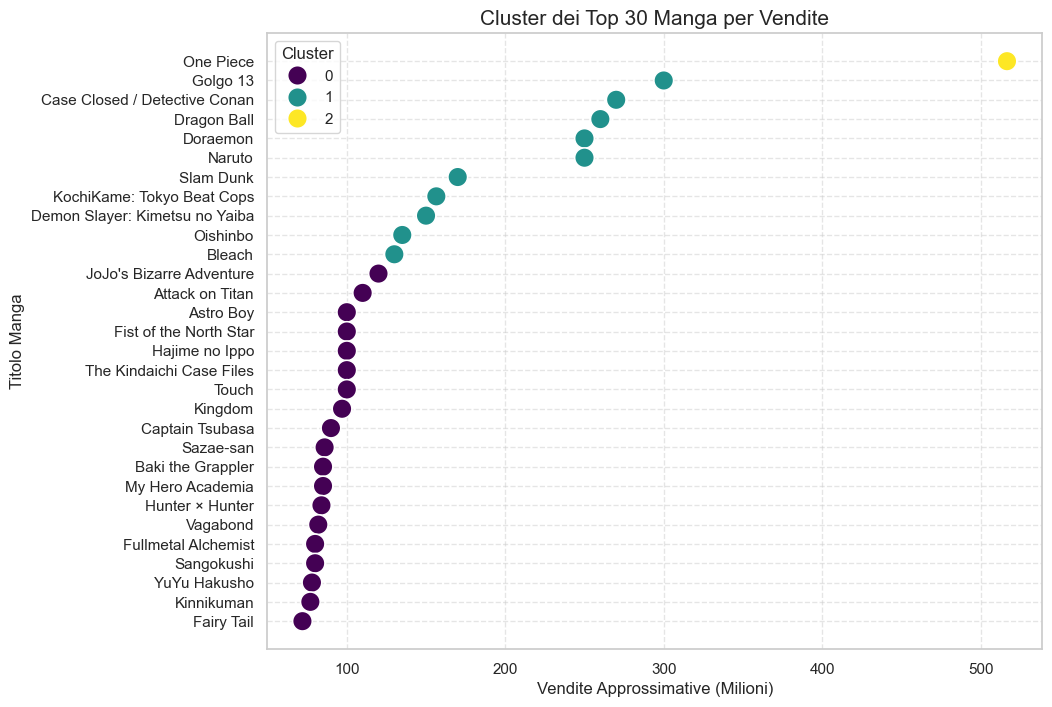

In [24]:
# Selezioniamo solo i primi 30 manga con più vendite
df_top30 = df.sort_values('Approximate sales in million(s)', ascending=False).head(30)

# 3. Creiamo il Grafico
plt.figure(figsize=(10, 8)) # Dimensioni: 10 larghezza, 8 altezza

sns.scatterplot(
    data=df_top30,
    x='Approximate sales in million(s)',
    y='Manga series',
    hue='Cluster',      # Colora i pallini in base al gruppo di appartenenza
    palette='viridis',  # Schema di colori
    s=200               # Dimensione dei pallini (più grandi per vederli meglio)
)

plt.title('Cluster dei Top 30 Manga per Vendite', fontsize=15)
plt.xlabel('Vendite Approssimative (Milioni)', fontsize=12)
plt.ylabel('Titolo Manga', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Aggiunge una griglia leggera
plt.show()

In [25]:
import joblib

# Salva il modello 'rf' in un file chiamato 'modello_manga.pkl'
joblib.dump(rf, 'modello_manga.pkl')

print("Modello salvato correttamente nella cartella del progetto!")

Modello salvato correttamente nella cartella del progetto!
